In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
'''
Load result files
'''
'''
def concat_d4PDF_dfs():
    d4PDF_dfs = {'TA':pd.read_csv('/nesi/project/niwa00015/queenle/results/d4PDF_TA_perfect_model_results.csv',\
                  names=result_dfs['HadGEM3'].columns),
                 'ROF':pd.read_csv('/nesi/project/niwa00015/queenle/results/d4PDF_ROF_perfect_model_results.csv',\
                  names=result_dfs['HadGEM3'].columns),
                 'PRECIPI':pd.read_csv('/nesi/project/niwa00015/queenle/results/d4PDF_PRECIPI_perfect_model_results.csv',\
                  names=result_dfs['HadGEM3'].columns)}
    
    return(pd.concat([d4PDF_dfs['TA'],d4PDF_dfs['ROF'],d4PDF_dfs['PRECIPI']]))

result_dfs = {'HadGEM3':pd.read_csv('/nesi/project/niwa00015/queenle/results/HadGEM3_perfect_model_results_1961-2015.csv'),
              'ECHAM5':pd.read_csv('/nesi/project/niwa00015/queenle/results/ECHAM5_perfect_model_results.csv')}
result_dfs['d4PDF'] = concat_d4PDF_dfs()
'''



results_dir = '/nesi/project/niwa00015/queenle/results/'

result_dfs = {'HadGEM3':pd.read_csv(results_dir + 'HadGEM3_PM_results_final.csv'),
              'ECHAM5':pd.read_csv(results_dir + 'ECHAM5_PM_results_final.csv'),
              'd4PDF':pd.read_csv(results_dir + 'd4PDF_PM_results_final.csv')}

'''
HadGEM3_tas = pd.read_csv(results_dir + 'HadGEM3_tas_perfect_model_results.csv',names = ['model','variable','season','trunc','ensemble_member','time_step','ant_upper','ant_lower','ant_best','nat_upper','nat_lower','nat_best','notes'])
ECHAM5_tas = pd.read_csv(results_dir + 'ECHAM5_tas_perfect_model_results.csv').drop(0)
for col in ['trunc','ant_upper','ant_lower','ant_best','nat_upper','nat_lower','nat_best']:
    ECHAM5_tas[col] = ECHAM5_tas[col].astype(float)

result_dfs['HadGEM3'] = pd.concat([result_dfs['HadGEM3'],HadGEM3_tas])
result_dfs['ECHAM5'] = pd.concat([result_dfs['ECHAM5'],ECHAM5_tas])

for model in result_dfs:
    result_dfs[model].to_csv(results_dir + model + '_PM_results_final.csv')
'''

'''
expected sizes:

HadGEM3: 15mem * 10trunc * 3var * 4season * 3timesteps = 5400
ECHAM5:  50mem * 45trunc * 4var * 4season * 3timesteps = 108000
d4PDF:  100mem * 95trunc * 3var * 4season * 3timesteps = 342000 
'''

def check_sizes(df):
    if len(df['HadGEM3']) != 5400:
        print('HadGEM3 wrong size: ' + str(len(df['HadGEM3'])))
        
    if len(df['ECHAM5']) != 108000:
        print('ECHAM5 wrong size: ' + str(len(df['ECHAM5'])))
    
    if len(df['d4PDF']) != 342000:
        print('d4PDF wrong size')
        
check_sizes(result_dfs)



In [3]:
var_indices = ['temp','precipitation','runoff']
var_dict = {'ECHAM5':['tas','pr','mrro'],
            'HadGEM3':['tas','pr'],
            'd4PDF':['TA','PRECIPI','ROF']}

trunc_dict = {'HadGEM3':10,
              'ECHAM5':36,
              'd4PDF':60}

time_window_dict = {'ECHAM5':('1979','2018'),
                    'HadGEM3':('1961','2013'),
                    'd4PDF':('1951','2021')}

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

season_titles = {'winter':'Winter','spring':'Spring','summer':'Summer','autumn':'Autumn'}

ensemble_members_dict = {'ECHAM5':['ens01', 'ens02', 'ens03', 'ens04', 'ens05', 'ens06', 'ens07', 'ens08', 'ens09', 'ens10', 'ens11', 'ens12', 'ens13', 'ens14', 'ens15', 'ens16', 'ens17', 'ens18', 'ens19', 'ens20', 'ens21', 'ens22', 'ens23', 'ens24', 'ens25',\
                                    'ens26', 'ens27', 'ens28', 'ens29', 'ens30', 'ens31', 'ens32', 'ens33', 'ens34', 'ens35', 'ens36', 'ens37', 'ens38', 'ens39', 'ens40', 'ens41', 'ens42', 'ens43', 'ens44', 'ens45', 'ens46', 'ens47', 'ens48', 'ens49', 'ens50'],
                         'HadGEM3':['r1i1p1','r1i1p11','r1i1p13','r1i1p15','r1i1p3','r1i1p5','r1i1p7','r1i1p9',
                                    'r1i1p10','r1i1p12','r1i1p14','r1i1p2','r1i1p4','r1i1p6','r1i1p8'],
                         'd4PDF':['m001', 'm002', 'm003', 'm004', 'm005', 'm006', 'm007', 'm008', 'm009', 'm010', 'm011', 'm012', 'm013', 'm014', 'm015', 'm016', 'm017', 'm018', 'm019', 'm020', 'm021', 'm022', 'm023', 'm024', 'm025', \
                                  'm026', 'm027', 'm028', 'm029', 'm030', 'm031', 'm032', 'm033', 'm034', 'm035', 'm036', 'm037', 'm038', 'm039', 'm040', 'm041', 'm042', 'm043', 'm044', 'm045', 'm046', 'm047', 'm048', 'm049', 'm050', \
                                  'm051', 'm052', 'm053', 'm054', 'm055', 'm056', 'm057', 'm058', 'm059', 'm060', 'm061', 'm062', 'm063', 'm064', 'm065', 'm066', 'm067', 'm068', 'm069', 'm070', 'm071', 'm072', 'm073', 'm074', 'm075', \
                                  'm076', 'm077', 'm078', 'm079', 'm080', 'm081', 'm082', 'm083', 'm084', 'm085', 'm086', 'm087', 'm088', 'm089', 'm090', 'm091', 'm092', 'm093', 'm094', 'm095', 'm096', 'm097', 'm098', 'm099', 'm100']}


In [4]:
model = 'HadGEM3'
var = 'tas'
trunc = '10'
season = 'winter'
time_step = 'annual'

full_df = result_dfs[model]

df = full_df.query('variable==\''+var+'\'')# and trunc==\''+str(trunc)+'\'')# and time_step==\''+time_step+'\' and season==\''+season+'\'').sort_values('ant_best')

In [6]:
result_dfs

{'HadGEM3':       Unnamed: 0    model variable  season  trunc ensemble_member time_step  \
 0              0  HadGEM3   tasmax  winter      3          r1i1p1    annual   
 1              1  HadGEM3   tasmax  winter      4          r1i1p1    annual   
 2              2  HadGEM3   tasmax  winter      5          r1i1p1    annual   
 3              3  HadGEM3   tasmax  winter      6          r1i1p1    annual   
 4              4  HadGEM3   tasmax  winter      7          r1i1p1    annual   
 ...          ...      ...      ...     ...    ...             ...       ...   
 5395        1795  HadGEM3      tas  autumn      8          r1i1p8       10Y   
 5396        1796  HadGEM3      tas  autumn      9          r1i1p8       10Y   
 5397        1797  HadGEM3      tas  autumn     10          r1i1p8       10Y   
 5398        1798  HadGEM3      tas  autumn     11          r1i1p8       10Y   
 5399        1799  HadGEM3      tas  autumn     12          r1i1p8       10Y   
 
       ant_upper  ant_lower

In [4]:
'''
Make single season PM Summary figures for each variable
'''

def plot_single_season_PM_summary(ax,i,j,model,var,trunc,season,time_step,font,label):
    '''
    print(model)
    print(var)
    print(trunc)
    print(season)
    print(time_step)
    '''
    if var != 'no_runoff':
        full_df = result_dfs[model]


        df = full_df.query('variable==\''+var+'\' and trunc==\''+str(trunc)+'\' and time_step==\''+time_step+'\' and season==\''+season+'\'').sort_values('ant_best')

        #print(df)

        x_vals = [i for i in range(len(df['ensemble_member']))]

        ax.scatter(x_vals,df['ant_best'],color='red',marker='.',label='ANT')
        ax.scatter(x_vals,df['ant_upper'],color='red',marker='_')
        ax.scatter(x_vals,df['ant_lower'],color='red',marker='_')
        ax.vlines(x_vals,df['ant_lower'],df['ant_upper'],color='red')

        ax.scatter(x_vals,df['nat_best'],color='blue',marker='.',label='NAT')
        ax.scatter(x_vals,df['nat_upper'],color='blue',marker='_')
        ax.scatter(x_vals,df['nat_lower'],color='blue',marker='_')
        ax.vlines(x_vals,df['nat_lower'],df['nat_upper'],color='blue')

        ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
        ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
        ax.set_ylim(-2.5,4.5)
    
    if j == 0:
        font['size'] = 18
        ax.set_ylabel('Scaling Factor',fontdict=font)
        ax.set_yticks([-2,-1,0,1,2,3,4])
        ax.set_yticklabels(['-2','-1','0','1','2','3','4'],fontdict=font)
        font['size'] = 22
        ax.text(-.9,.5,var_indices[i],transform=ax.transAxes,fontdict=font,rotation='vertical',va='center')
        
    if i == 0:
        font['size'] = 22
        ax.set_title(model + '\n' + '(' + time_window_dict[model][0] + '-' + time_window_dict[model][1] + ')',fontdict=font)
        font['size'] = 18
        font['size'] = 22
        
    if i == 0 and j == 2:
        ax.legend(fontsize=18,loc='upper right', markerscale=2.5)

    if i == 2:
        font['size'] = 18
        ax.set_xlabel('Ens. Member',fontdict=font)
        font['size'] = 22

    font['size'] = 18
    if model == 'HadGEM3':
        ax.set_xlim(-1,15)
        ax.set_xticks([10*i for i in range(2)])
        ax.set_xticklabels([str(10*j) if i == 2 else '' for j in range(2)],fontdict=font)
    elif model == 'ECHAM5':
        ax.set_xlim(-1,50)
        ax.set_xticks([20*i for i in range(3)])
        ax.set_xticklabels([str(20*j) if i == 2 else '' for j in range(3)],fontdict=font)
    elif model == 'd4PDF':
        ax.set_xlim(-1,100)
        ax.set_xticks([20*i for i in range(6)])
        ax.set_xticklabels([str(20*j) if i == 2 else '' for j in range(6)],fontdict=font)
    font['size'] = 22
    
    ax.text(2.8,3.5,label,fontdict=font,ha='center')


    
labels = [['(a)','(b)','(c)'],
          ['(d)','(e)','(f)'],
          ['(h)','(i)','(j)']]

for season in ['winter','spring','summer','autumn']:
    fig,axs = plt.subplots(3, 3, figsize=(16,12),gridspec_kw={'width_ratios': [1,50/15,100/15]}, sharey=True)

    time_step = 'annual'
    for i in [0,1,2]:

        for j,model in enumerate(['HadGEM3','ECHAM5','d4PDF']):

            try:
                var = var_dict[model][i]
                plot_single_season_PM_summary(axs[i][j],i,j,model,var_dict[model][i],trunc_dict[model],season,time_step,font,labels[i][j])
            except:
                plot_single_season_PM_summary(axs[i][j],i,j,model,'no_runoff',trunc_dict[model],season,time_step,font,labels[i][j])

    plt.tight_layout(pad=3)
    fig.patch.set_alpha(1)

    fig.savefig('/home/queenle/hydro_attribution/dissertation/figures/'+season+'_PM_summary_all_vars.png',dpi=300)#,frameon=True)#,bbox_inches='tight')
    plt.close()
    


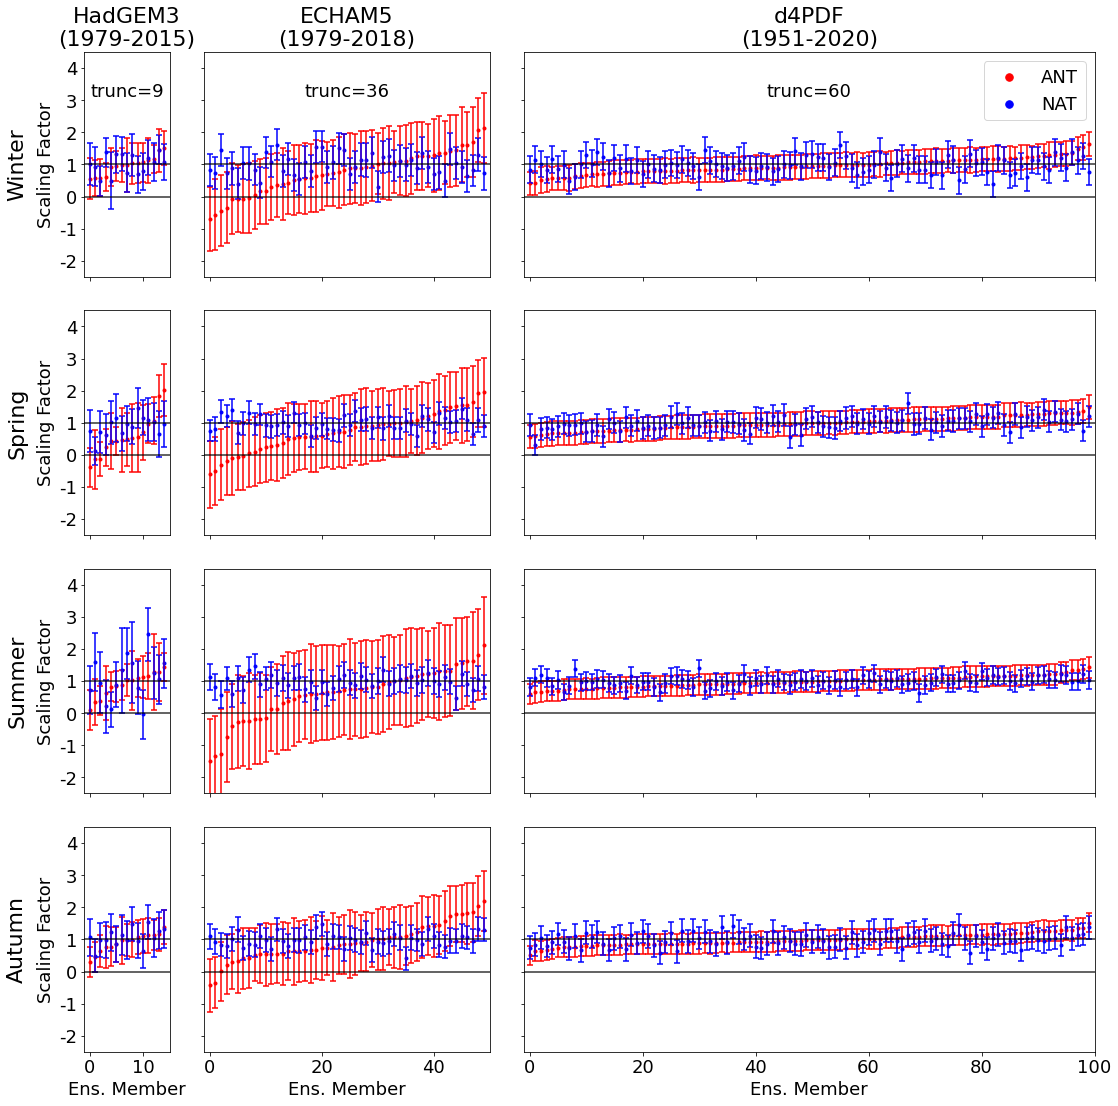

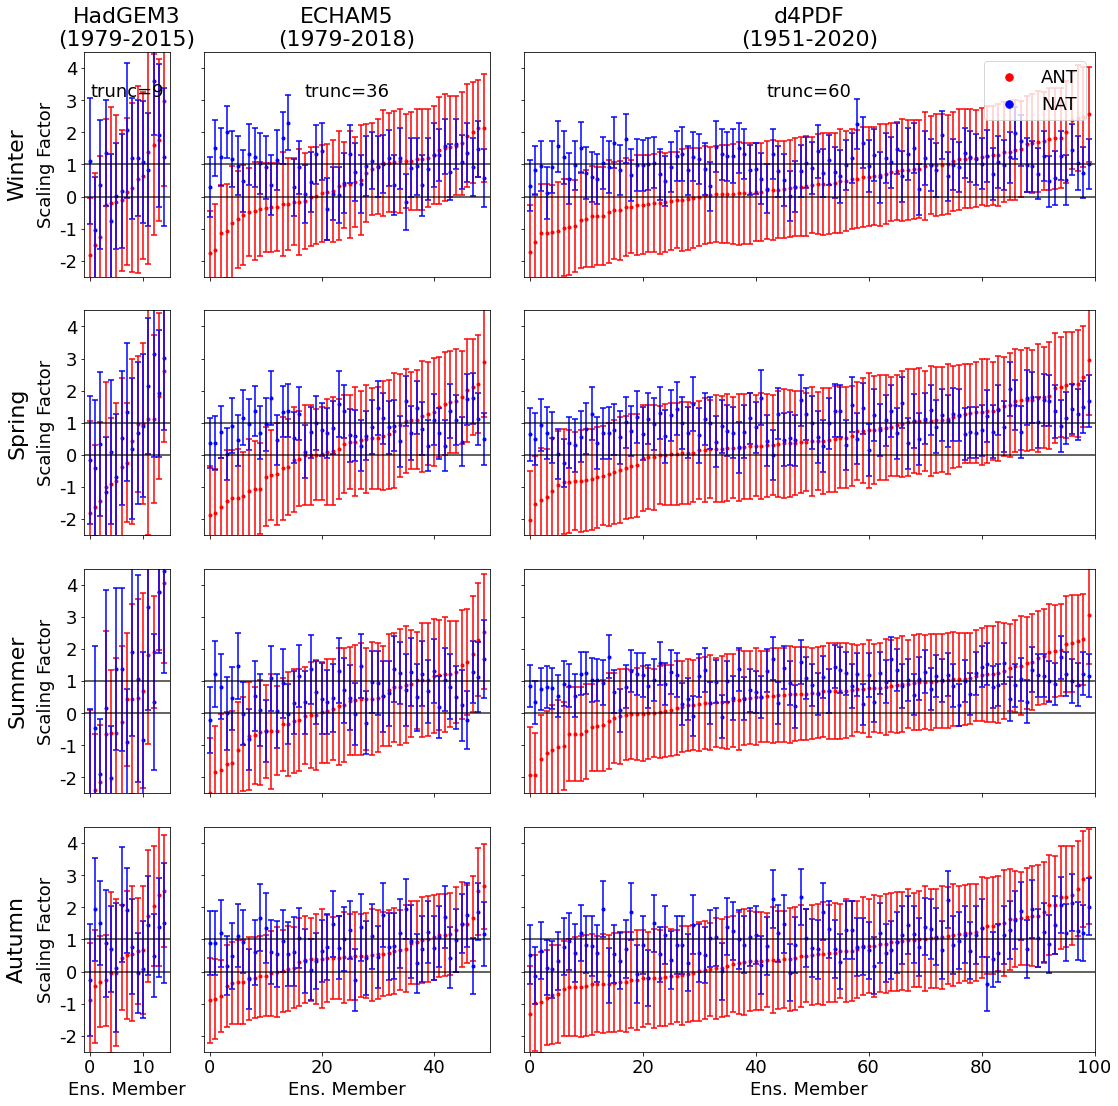

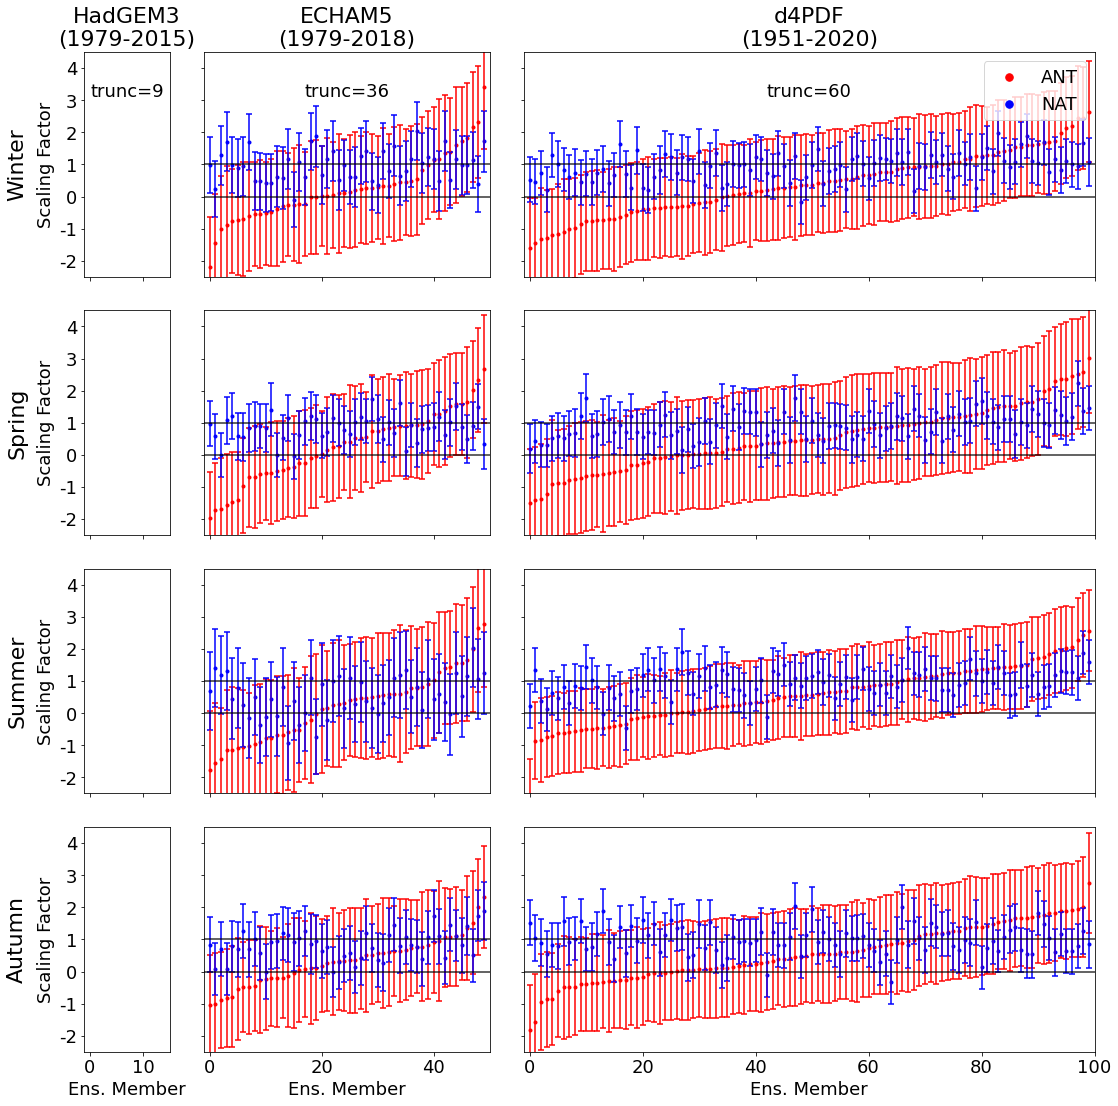

In [7]:
'''
Make seasonal PM Summary figures for each variable
'''

def plot_seasonal_PM_summary(ax,i,j,model,var,trunc,season,time_step,font):

    if var != 'no_runoff':
        full_df = result_dfs[model]


        df = full_df.query('variable==\''+var+'\' and trunc==\''+str(trunc)+'\' and time_step==\''+time_step+'\' and season==\''+season+'\'').sort_values('ant_best')


        x_vals = [i for i in range(len(df['ensemble_member']))]

        ax.scatter(x_vals,df['ant_best'],color='red',marker='.',label='ANT')
        ax.scatter(x_vals,df['ant_upper'],color='red',marker='_')
        ax.scatter(x_vals,df['ant_lower'],color='red',marker='_')
        ax.vlines(x_vals,df['ant_lower'],df['ant_upper'],color='red')

        ax.scatter(x_vals,df['nat_best'],color='blue',marker='.',label='NAT')
        ax.scatter(x_vals,df['nat_upper'],color='blue',marker='_')
        ax.scatter(x_vals,df['nat_lower'],color='blue',marker='_')
        ax.vlines(x_vals,df['nat_lower'],df['nat_upper'],color='blue')

        ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
        ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
        ax.set_ylim(-2.5,4.5)
    
    if j == 0:
        font['size'] = 18
        ax.set_ylabel('Scaling Factor',fontdict=font)
        ax.set_yticks([-2,-1,0,1,2,3,4])
        ax.set_yticklabels(['-2','-1','0','1','2','3','4'],fontdict=font)
        font['size'] = 22
        ax.text(-.9,.5,season_titles[season],transform=ax.transAxes,fontdict=font,rotation='vertical',va='center')
        
    if i == 0:
        font['size'] = 22
        ax.set_title(model + '\n' + '(' + time_window_dict[model][0] + '-' + time_window_dict[model][1] + ')',fontdict=font)
        font['size'] = 18
        ax.text(.5,.8,'trunc='+str(trunc_dict[model]),transform=ax.transAxes,fontdict=font,ha='center')
        font['size'] = 22
        
    if i == 0 and j == 2:
        ax.legend(fontsize=18,loc='upper right', markerscale=2.5)

    if i == 3:
        font['size'] = 18
        ax.set_xlabel('Ens. Member',fontdict=font)
        font['size'] = 22

    font['size'] = 18
    if model == 'HadGEM3':
        ax.set_xlim(-1,15)
        ax.set_xticks([10*i for i in range(2)])
        ax.set_xticklabels([str(10*j) if i == 3 else '' for j in range(2)],fontdict=font)
    elif model == 'ECHAM5':
        ax.set_xlim(-1,50)
        ax.set_xticks([20*i for i in range(3)])
        ax.set_xticklabels([str(20*j) if i == 3 else '' for j in range(3)],fontdict=font)
    elif model == 'd4PDF':
        ax.set_xlim(-1,100)
        ax.set_xticks([20*i for i in range(6)])
        ax.set_xticklabels([str(20*j) if i == 3 else '' for j in range(6)],fontdict=font)
    font['size'] = 22

    
time_step = 'annual'

for var_index in [0,1,2]:
    var_name = var_indices[var_index]
    
    fig,axs = plt.subplots(4, 3, figsize=(16,16),gridspec_kw={'width_ratios': [1,50/15,100/15]}, sharey=True)

    for i,season in enumerate(['winter','spring','summer','autumn']):

        for j,model in enumerate(['HadGEM3','ECHAM5','d4PDF']):

            try:
                plot_seasonal_PM_summary(axs[i][j],i,j,model,var_dict[model][var_index],trunc_dict[model],season,time_step,font)
            except:
                plot_seasonal_PM_summary(axs[i][j],i,j,model,'no_runoff',trunc_dict[model],season,time_step,font)

    plt.tight_layout(pad=3)
    fig.patch.set_alpha(1)
    
    #fig.savefig('/home/queenle/hydro_attribution/dissertation/figures/'+var_name+'_seasonal_perfect_model_summary.png',dpi=300)#,frameon=True)#,bbox_inches='tight')
    #plt.close()



In [5]:
'''
Make example PM test for each model
'''

def plot_single_season_PM_summary(ax,i,j,model,var,mem,season,time_step,font):

    if var != 'no_runoff':
        full_df = result_dfs[model]


        df = full_df.query('variable==\''+var+'\' and ensemble_member==\''+str(mem)+'\' and time_step==\''+time_step+'\' and season==\''+season+'\'').sort_values('trunc')


        x_vals = df['trunc']

        ax.scatter(x_vals,df['ant_best'],color='red',marker='.',label='ANT')
        ax.scatter(x_vals,df['ant_upper'],color='red',marker='_')
        ax.scatter(x_vals,df['ant_lower'],color='red',marker='_')
        ax.vlines(x_vals,df['ant_lower'],df['ant_upper'],color='red')

        ax.scatter(x_vals,df['nat_best'],color='blue',marker='.',label='NAT')
        ax.scatter(x_vals,df['nat_upper'],color='blue',marker='_')
        ax.scatter(x_vals,df['nat_lower'],color='blue',marker='_')
        ax.vlines(x_vals,df['nat_lower'],df['nat_upper'],color='blue')

        ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
        ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
        ax.set_ylim(-2.5,4.5)
    
    if j == 0:
        font['size'] = 18
        ax.set_ylabel('Scaling Factor',fontdict=font)
        ax.set_yticks([-2,-1,0,1,2,3,4])
        ax.set_yticklabels(['-2','-1','0','1','2','3','4'],fontdict=font)
        font['size'] = 22
        ax.text(-.9,.5,var_indices[i],transform=ax.transAxes,fontdict=font,rotation='vertical',va='center')
        
    if i == 0:
        font['size'] = 22
        ax.set_title(model + '\n' + '(' + time_window_dict[model][0] + '-' + time_window_dict[model][1] + ')',fontdict=font)
        
    if i == 0 and j == 2:
        ax.legend(fontsize=18,loc='upper right', markerscale=2.5)

    if i == 2:
        font['size'] = 18
        ax.set_xlabel('Truncation',fontdict=font)
        font['size'] = 22

    font['size'] = 18
    if model == 'HadGEM3':
        ax.set_xlim(-1,15)
        ax.set_xticks([10*i for i in range(2)])
        ax.set_xticklabels([str(10*j) if i == 2 else '' for j in range(2)],fontdict=font)
    elif model == 'ECHAM5':
        ax.set_xlim(-1,50)
        ax.set_xticks([20*i for i in range(3)])
        ax.set_xticklabels([str(20*j) if i == 2 else '' for j in range(3)],fontdict=font)
    elif model == 'd4PDF':
        ax.set_xlim(-1,100)
        ax.set_xticks([20*i for i in range(6)])
        ax.set_xticklabels([str(20*j) if i == 2 else '' for j in range(6)],fontdict=font)
    font['size'] = 22

    

fig,axs = plt.subplots(3, 3, figsize=(16,12),gridspec_kw={'width_ratios': [1,50/15,100/15]}, sharey=True)

season = 'winter'
time_step = 'annual'
for i in [0,1,2]:

    for j,model in enumerate(['HadGEM3','ECHAM5','d4PDF']):
        
        ens_mem = ensemble_members_dict[model][1]
        
        try:
            var = var_dict[model][i]
            plot_single_season_PM_summary(axs[i][j],i,j,model,var_dict[model][i],ens_mem,season,time_step,font)
        except:
            plot_single_season_PM_summary(axs[i][j],i,j,model,'no_runoff',ens_mem,season,time_step,font)

plt.tight_layout(pad=3)
fig.patch.set_alpha(1)

fig.savefig('/home/queenle/hydro_attribution/dissertation/figures/example_PM_test_winter_tas.png',dpi=300)
plt.close()

